In [28]:
%pip install pandas numpy plotly streamlit google-genai

Note: you may need to restart the kernel to use updated packages.


In [29]:
from getpass import getpass

api_key = getpass("Enter your Gemini API key: ")
print("API key received successfully.")

Enter your Gemini API key:  ········


API key received successfully.


In [30]:
from google import genai

client = genai.Client(api_key=api_key)

response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents="Explain data analytics in one simple sentence."
)

print(response.text)

Data analytics is the process of examining raw information to uncover patterns, answer questions, and help make better decisions.


In [55]:
import pandas as pd
import numpy as np
import plotly.express as px
import streamlit as st
from google import genai
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [32]:
import pandas as pd

df = pd.read_csv(r"C:\Users\VIVOBOOK\Desktop\airbnb\listings.csv")


In [33]:
df.shape

(490, 90)

In [34]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.75,4.63,NaN,NaN,2,1,1,0,3.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.47
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,4.87,4.77,4.68,NaN,NaN,2,1,1,0,3.71


In [35]:
# Display all column names
for col in df.columns:
    print(col)

id
listing_url
scrape_id
last_scraped
source
name
description
neighborhood_overview
picture_url
host_id
host_url
host_profile_id
host_profile_url
host_name
host_since
hosts_time_as_user_years
hosts_time_as_user_months
hosts_time_as_host_years
hosts_time_as_host_months
host_location
host_about
host_response_time
host_response_rate
host_acceptance_rate
host_is_superhost
host_thumbnail_url
host_picture_url
host_neighbourhood
host_listings_count
host_total_listings_count
host_verifications
host_has_profile_pic
host_identity_verified
neighbourhood
neighbourhood_cleansed
neighbourhood_group_cleansed
latitude
longitude
property_type
room_type
accommodates
bathrooms
bathrooms_text
bedrooms
beds
amenities
price
price_quote_checkin_date
price_quote_checkout_date
price_quote_total_price
price_quote_price_per_night
price_quote_raw
minimum_nights
maximum_nights
minimum_minimum_nights
maximum_minimum_nights
minimum_maximum_nights
maximum_maximum_nights
minimum_nights_avg_ntm
maximum_nights_avg_ntm
c

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            490 non-null    int64  
 1   listing_url                                   490 non-null    object 
 2   scrape_id                                     490 non-null    int64  
 3   last_scraped                                  490 non-null    object 
 4   source                                        490 non-null    object 
 5   name                                          490 non-null    object 
 6   description                                   481 non-null    object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   490 non-null    object 
 9   host_id                                       490 non-null    int

In [37]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.head(20))

neighborhood_overview           490
host_since                      490
host_response_time              490
host_thumbnail_url              490
host_acceptance_rate            490
host_response_rate              490
host_verifications              490
neighbourhood                   490
host_total_listings_count       490
host_neighbourhood              490
calendar_updated                490
instant_bookable                490
license                         490
neighbourhood_group_cleansed    490
host_about                      230
host_location                   142
bedrooms                        112
review_scores_cleanliness        60
review_scores_accuracy           60
first_review                     60
dtype: int64

In [38]:
# Keep the original dataframe unchanged
df_clean=df.copy()

In [39]:
# Remove columns that have no values at all
empty_cols=df_clean.columns[df_clean.isna().all()].tolist()
df_clean=df_clean.drop(columns=empty_cols)
print("Removed completely empty columns:", empty_cols)
print("Cleaned dataset shape:",df_clean.shape)

Removed completely empty columns: ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'license', 'instant_bookable']
Cleaned dataset shape: (490, 76)


In [40]:
# Inspect the two price-related fields
print("price examples:")
print(df_clean['price'].head(10).tolist())

print("price per night examples:")
print(df_clean["price_quote_price_per_night"].head(10).tolist())

price examples:
['$80.43', '$211.00', '$97.00', '$160.00', '$86.00', '$58.00', '$277.31', '$62.87', '$64.00', '$313.00']
price per night examples:
[80.43, 211.0, 97.0, 160.0, 86.0, 58.0, 277.31, 62.87, 64.0, 313.0]


Convert prices and check missing values

In [41]:
# Convert price strings like "$80.43" into numbers
df_clean["price_numeric"]=pd.to_numeric(
    df_clean["price"].str.replace("$"," ",regex=False).str.replace(","," ",regex=False)
                                        ,errors="coerce")
# Compare the two price columns
df_clean[["price","price_numeric","price_quote_price_per_night"]].head(10)

,price,price_numeric,price_quote_price_per_night
0,$80.43,80.43,80.43
1,$211.00,211.00,211.00
2,$97.00,97.00,97.00
3,$160.00,160.00,160.00
4,$86.00,86.00,86.00
5,$58.00,58.00,58.00
6,$277.31,277.31,277.31
7,$62.87,62.87,62.87
8,$64.00,64.00,64.00
9,$313.00,313.00,313.00


In [42]:
# Check missing values in important analysis columns
cols = [
    "price_numeric",
    "price_quote_price_per_night",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "number_of_reviews",
    "review_scores_rating"
]
df_clean[cols].isna().sum()

price_numeric                   36
price_quote_price_per_night     32
room_type                        0
property_type                    0
accommodates                     0
bedrooms                       112
number_of_reviews                0
review_scores_rating            60
dtype: int64

In [43]:
df_clean['price_quote_price_per_night']

0       80.43
1      211.00
2       97.00
3      160.00
4       86.00
        ...  
485    149.00
486    213.00
487    114.50
488     86.00
489     44.75
Name: price_quote_price_per_night, Length: 490, dtype: float64

In [44]:
df_clean["nightly_price"] = df_clean["price_quote_price_per_night"].fillna(
    df_clean["price_numeric"]
)
print("Listings with a usable nightly price:", df_clean["nightly_price"].notna().sum())

Listings with a usable nightly price: 458


In [45]:
df_clean["nightly_price"].isna().sum() #remaining 32 values are null values from both the tables

np.int64(32)

In [46]:
df_clean["nightly_price"].describe()

count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: nightly_price, dtype: float64

The average is higher than the median, which may be because a small number of very expensive listings pull the average upward

In [47]:
df_clean[["name","room_type","nightly_price"]].sort_values(by="nightly_price",ascending=False).head(10)

,name,room_type,nightly_price
113,The Historic Jesse Buel Farmhouse,Entire home/apt,1701.00
117,🪴 Historic & Homey 1 Bdrm Apt @ Downtown Albany,Entire home/apt,1267.00
220,ABBA House Retreat: Centrally Located Grand Manor,Entire home/apt,1265.00
78,"/ New Giant Victorian \ 7beds 6 baths + 2x 85""...",Entire home/apt,1040.50
24,/zBig Blue Ranch\ 1962 SUNY Eagle Hill 4Beds 2...,Entire home/apt,845.75
146,Historic Washington Park Inn | Full Mansion | ...,Shared room,840.00
94,+ Perfect place to make memories with loved on...,Entire home/apt,819.00
100,/ Sauna Garden Getaway\ 1943 SUNY Eagle Hill,Entire home/apt,700.50
211,5BR/4BA Retreat | Fire Pit + BBQ,Entire home/apt,625.00
162,Modern Cottage-Perfect for Families!,Entire home/apt,587.00


In [48]:
import plotly.express as px
fig=px.histogram(
    df_clean.dropna(subset=["nightly_price"]),
    x="nightly_price",
    nbins=30,
    title="Distribution of Airbnb Nightly prices in Albany",
    labels={"nightly_price": "Price per night (USD)"},
    template="plotly_white"
                   )
fig.show()

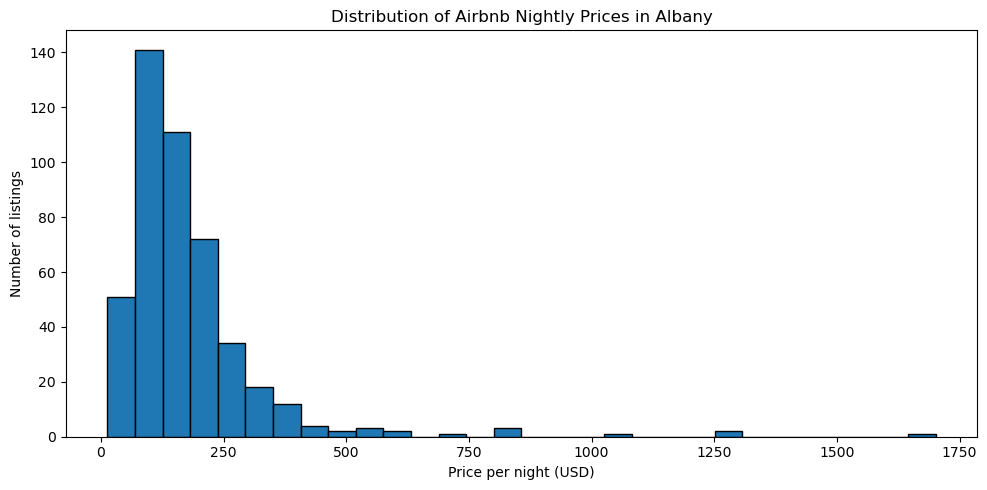

In [57]:
import matplotlib.pyplot as plt

prices = df_clean["nightly_price"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(prices, bins=30, edgecolor="black")
plt.title("Distribution of Airbnb Nightly Prices in Albany")
plt.xlabel("Price per night (USD)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

In [50]:
top10 = df_clean.nlargest(10, "nightly_price")

display(top10[
    [
        "name",
        "price",
        "price_numeric",
        "price_quote_price_per_night",
        "price_quote_checkin_date",
        "price_quote_checkout_date",
        "nightly_price"
    ]
])

,name,price,price_numeric,price_quote_price_per_night,price_quote_checkin_date,price_quote_checkout_date,nightly_price
113,The Historic Jesse Buel Farmhouse,"$1,701.00",NaN,1701.00,2026-06-25,2026-06-26,1701.00
117,🪴 Historic & Homey 1 Bdrm Apt @ Downtown Albany,"$1,267.00",NaN,1267.00,2026-06-16,2026-06-17,1267.00
220,ABBA House Retreat: Centrally Located Grand Manor,"$1,265.00",NaN,1265.00,2026-07-05,2026-07-06,1265.00
78,"/ New Giant Victorian \ 7beds 6 baths + 2x 85""...","$1,040.50",NaN,1040.50,2026-06-16,2026-06-20,1040.50
24,/zBig Blue Ranch\ 1962 SUNY Eagle Hill 4Beds 2...,$845.75,845.75,845.75,2026-06-17,2026-06-21,845.75
146,Historic Washington Park Inn | Full Mansion | ...,$840.00,840.00,840.00,2026-06-24,2026-06-25,840.00
94,+ Perfect place to make memories with loved on...,$819.00,819.00,819.00,2026-06-17,2026-06-19,819.00
100,/ Sauna Garden Getaway\ 1943 SUNY Eagle Hill,$700.50,700.50,700.50,2026-06-25,2026-06-29,700.50
211,5BR/4BA Retreat | Fire Pit + BBQ,$625.00,625.00,625.00,2026-06-16,2026-06-18,625.00
162,Modern Cottage-Perfect for Families!,$587.00,587.00,587.00,2026-06-22,2026-06-23,587.00


In [51]:
df_clean["room_type"].value_counts()

room_type
Entire home/apt    345
Private room       135
Hotel room           9
Shared room          1
Name: count, dtype: int64

In [52]:
room_counts = df_clean["room_type"].value_counts().reset_index()
room_counts.columns = ["room_type", "listing_count"]

fig = px.bar(
    room_counts,
    x="room_type",
    y="listing_count",
    title="Airbnb Listings by Room Type in Albany",
    labels={
        "room_type": "Room type",
        "listing_count": "Number of listings"
    },
    text="listing_count",
    template="plotly_white"
)

fig.show()

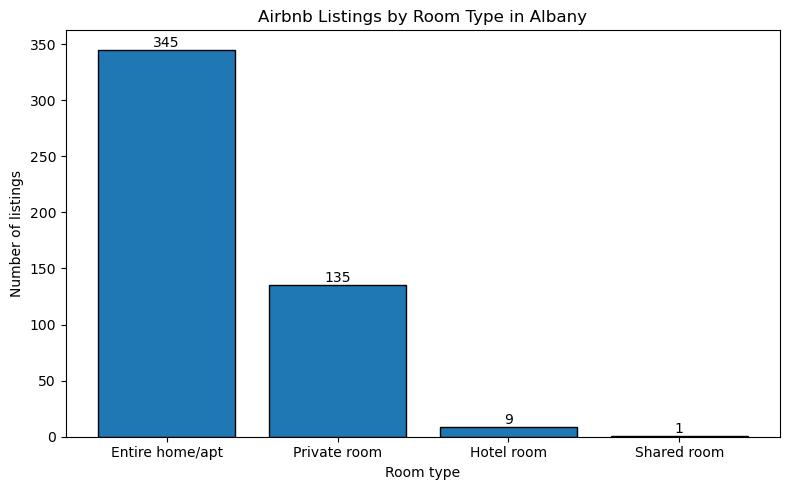

In [58]:
import matplotlib.pyplot as plt

room_counts = df_clean["room_type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(room_counts.index, room_counts.values, edgecolor="black")
plt.title("Airbnb Listings by Room Type in Albany")
plt.xlabel("Room type")
plt.ylabel("Number of listings")

for i, count in enumerate(room_counts.values):
    plt.text(i, count, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [53]:
price_by_room = (
    df_clean.groupby("room_type")["nightly_price"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(price_by_room)

,count,mean,median
room_type,,,
Shared room,1,840.00,840.00
Hotel room,8,217.00,186.00
Entire home/apt,322,208.47,166.00
Private room,127,89.94,71.82


In [54]:
dashboard_columns = [
    "id",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "nightly_price",
    "availability_30",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

dashboard_df = df_clean[dashboard_columns].copy()

dashboard_df.to_csv("albany_airbnb_dashboard.csv", index=False)

print("Saved dashboard dataset:", dashboard_df.shape)

Saved dashboard dataset: (490, 17)
